# Plot Figure 5A: Images of 3D Biofilms

**⚠️ Data Requirement — BioImageArchive:** This notebook loads fluorescence TIFF images directly from BioImageArchive. Update `BASE` to point to your local BioImageArchive directory.


In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from skimage.exposure import rescale_intensity

In [10]:
# -------- SHARED DISPLAY PARAMETERS --------
PHASE_PMIN, PHASE_PMAX = 1, 100
GFP_VMIN,  GFP_VMAX   = 1, 5000
MCH_VMIN,  MCH_VMAX   = 1, 5000
GAMMA = 1  # <1 brightens midtones


#Set path to BioImageArchive folder
BASE = Path("/Volumes/ScientificData/Users/Giulia(botgiu00)/Papers/bottacin2026/BioImageArchive/3DBiofilms")

# -------- PER-IMAGE SETTINGS --------
# Each entry: (stem, alpha, crop, output_name)
# crop = (y_start, y_end, x_start, x_end) or None for full image
IMAGES = [
    ("5_wt_mixed_pos1",  0.98, None,                    "mixed_blue_yellow_overlay"),
    ("5_wt_mixed_pos1",  1.00, (1550, 2050, 1160, 1660), "mixed_blue_yellow_overlay_cropped"),
    ("5_wt_small_pos1",  0.80, None,                    "small_blue_yellow_overlay"),
    ("5_wt_small_pos1",  0.80, (800,  1300, 1160, 1660), "small_blue_yellow_overlay_cropped"),
    ("5_wt_big_pos1",    0.70, None,                    "big_blue_yellow_overlay"),
    ("5_wt_big_pos1",    0.80, (900,  1400, 1230, 1730), "big_blue_yellow_overlay_cropped"),
    ("5_wt_medium_pos1", 0.80, None,                    "medium_blue_yellow_overlay"),
    ("5_wt_medium_pos1", 0.80, (1200, 1700, 1230, 1730), "medium_blue_yellow_overlay_cropped"),
]

# -------- MATPLOTLIB STYLE --------
plt.rcParams.update({
    'font.family': 'Arial', 'font.size': 8,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.dpi': 300, 'savefig.bbox': 'tight'
})

In [7]:
# -------- HELPER FUNCTIONS --------
def normalize(img, vmin, vmax, gamma=1.0):
    img = img.astype(float)
    img = np.clip((img - vmin) / (vmax - vmin), 0, 1)
    return img ** gamma  # gamma < 1 brightens

def plot_overlay(stem, alpha, crop, output_name):
    phase = imread(BASE / f"{stem}_phase.tif")
    gfp   = imread(BASE / f"{stem}_gfp.tif")
    mch   = imread(BASE / f"{stem}_mcherry.tif")

    if crop is not None:
        y0, y1, x0, x1 = crop
        phase = phase[y0:y1, x0:x1]
        gfp   = gfp[y0:y1, x0:x1]
        mch   = mch[y0:y1, x0:x1]

    phase_disp = rescale_intensity(phase, in_range=(
        np.percentile(phase, PHASE_PMIN), np.percentile(phase, PHASE_PMAX)))
    gfp_norm = normalize(gfp, GFP_VMIN, GFP_VMAX, GAMMA)
    mch_norm = normalize(mch, MCH_VMIN, MCH_VMAX, GAMMA)

    rgb_merge = np.zeros(phase.shape + (3,), dtype=np.float32)
    rgb_merge[..., 0] = mch_norm  # yellow = R + G
    rgb_merge[..., 1] = mch_norm
    rgb_merge[..., 2] = gfp_norm  # blue

    fig, ax = plt.subplots(figsize=(3, 2))
    ax.imshow(phase_disp, cmap='gray')
    ax.imshow(rgb_merge, alpha=alpha)
    ax.axis('off')
    fig.savefig(f"{output_name}.pdf", dpi=300)
    plt.show()

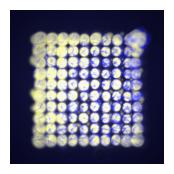

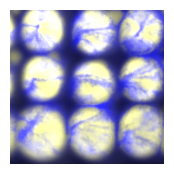

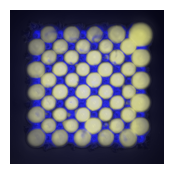

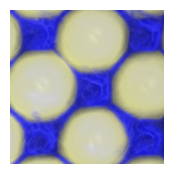

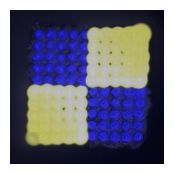

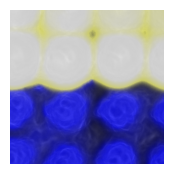

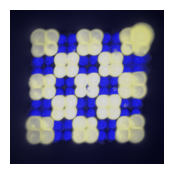

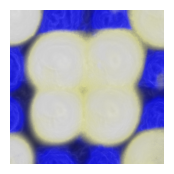

In [11]:
# -------- GENERATE ALL FIGURES --------
for stem, alpha, crop, output_name in IMAGES:
    plot_overlay(stem, alpha, crop, output_name)